# Assignment 6 — LSTM-Based Time-Series Forecasting

**Dataset:** Jena Climate Dataset

This notebook develops and compares LSTM-based forecasting models using different look-back windows on the Jena Climate dataset.

The objective is to study how the amount of historical information supplied to the LSTM affects time-series forecasting performance using multiple weather-related features.

- **24 time steps (4 hours)** — shorter historical context
- **48 time steps (8 hours)** — medium historical context
- **72 time steps (12 hours)** — longer historical context

## Objective

Develop an LSTM-based model for multivariate time-series forecasting using the Jena Climate dataset.

The experiment compares three different look-back windows:

- **24 time steps** — shorter historical context
- **48 time steps** — medium historical context
- **72 time steps** — longer historical context

Multiple weather-related features are provided as input to the LSTM, and the model predicts the **temperature at the next time step**.

Each model is evaluated using **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**.

The final comparison is based on the observed experimental results.

In [1]:
import os
import random
import time
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load the Dataset

The Jena Climate Dataset contains weather measurements recorded at regular time intervals at the Max Planck Institute for Biogeochemistry in Jena, Germany.

The dataset contains multiple weather-related variables, which makes it suitable for multivariate time-series forecasting.

The notebook checks whether the dataset already exists locally. If it does not, it downloads the dataset and saves it to the repository's `data/` directory.

In [2]:

DATA_DIR = "./data"
DATA_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")

DATA_URL = (
    "https://s3.amazonaws.com/keras-datasets/"
    "jena_climate_2009_2016.csv.zip"
)

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Dataset not found locally. Downloading...")

    zip_path = os.path.join(
        DATA_DIR,
        "jena_climate_2009_2016.csv.zip"
    )

    urllib.request.urlretrieve(DATA_URL, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Dataset downloaded and extracted to:", DATA_PATH)
else:
    print("Using local dataset:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset not found locally. Downloading...
Dataset downloaded and extracted to: ./data\jena_climate_2009_2016.csv
Dataset shape: (420451, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 2. Explore and Prepare the Dataset

The `Date Time` column contains the timestamp of each weather observation.

The dataset contains multiple weather measurements, including temperature, pressure, humidity, wind speed, and other atmospheric variables.

The timestamp is converted to a datetime format and the observations are sorted chronologically.

Before building the forecasting model, the dataset is checked for missing values and basic information about the available features.

In [3]:
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

df = df.sort_values("Date Time").reset_index(drop=True)

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Dataset shape: (420451, 15)

Missing values:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 420451 entries, 0 to 420450
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date Time        420451 non-null  datetime64[us]
 1   p (mbar)         420451 non-null  float64       
 2   T (degC)         420451 non-null  float64       
 3   Tpot (K)         420451 non-null  float64       
 4   Tdew (degC)      420451 non-null  float64       
 5   rh (%)           420451 non-null  float64       
 6   VPmax (mbar)     420451 non-null  float64       
 7   VPact (mbar)  

In [4]:
print("\nDescriptive statistics:")
df.describe()


Descriptive statistics:


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420451,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000,420451.000000
mean,2012-12-30 01:10:03.507662,989.212508,9.448567,283.491182,4.954011,76.007045,13.575089,9.532524,4.042483,6.021630,9.638982,1216.069883,2.130309,3.532381,174.726164
min,2009-01-01 00:10:00,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,0.000000,0.000000,0.000000
25%,2010-12-30 23:15:00,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.800000
50%,2012-12-29 22:00:00,989.570000,9.410000,283.460000,5.210000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.800000,1.760000,2.960000,198.100000
75%,2014-12-29 06:25:00,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.480000,1242.770000,2.860000,4.740000,234.100000
max,2017-01-01 00:00:00,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,14.630000,23.500000,360.000000
std,NaN,8.359454,8.423685,8.504820,6.730411,16.477126,7.739481,4.183895,4.897270,2.655973,4.235130,39.977065,1.541830,2.340482,86.675965


## 3. Select Features and Target

The Jena Climate Dataset contains 14 numerical weather measurements.

For multivariate forecasting, all 14 weather variables are used as input features, while **temperature (`T (degC)`)** is selected as the prediction target.

The model uses the historical values of all selected weather variables to predict the temperature at the next time step.

The `Date Time` column is retained separately for visualization and is not used as a numerical input feature.

In [5]:
FEATURE_COLUMNS = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

TARGET_COLUMN = "T (degC)"

features = df[FEATURE_COLUMNS].values.astype("float32")
target = df[TARGET_COLUMN].values.astype("float32")

print("Number of input features:", len(FEATURE_COLUMNS))
print("Feature shape:", features.shape)
print("Target shape:", target.shape)

Number of input features: 14
Feature shape: (420451, 14)
Target shape: (420451,)


## 4. Train-Test Split

Because this is a time-series forecasting problem, the data is split chronologically rather than randomly.

- **First 80%** → training data
- **Final 20%** → testing data

This ensures that the model is trained only on past observations and evaluated on future observations.

The chronological order of the observations is preserved throughout the experiment.

In [6]:
train_size = int(len(features) * 0.80)

train_features = features[:train_size]
test_features = features[train_size:]

train_target = target[:train_size]
test_target = target[train_size:]

print("Total observations:", len(features))
print("Training observations:", len(train_features))
print("Testing observations:", len(test_features))

print("\nTraining feature shape:", train_features.shape)
print("Testing feature shape:", test_features.shape)

print("\nTraining target shape:", train_target.shape)
print("Testing target shape:", test_target.shape)

Total observations: 420451
Training observations: 336360
Testing observations: 84091

Training feature shape: (336360, 14)
Testing feature shape: (84091, 14)

Training target shape: (336360,)
Testing target shape: (84091,)


## 5. Normalize the Data

The input features have different numerical ranges, so Min-Max scaling is applied to the feature variables.

The target temperature is also scaled separately.

Both scalers are fitted **only on the training data** and then used to transform the training and testing data. This prevents information from the future test period from influencing the scaling process.

In [7]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

train_features_scaled = feature_scaler.fit_transform(train_features)
test_features_scaled = feature_scaler.transform(test_features)

train_target_scaled = target_scaler.fit_transform(
    train_target.reshape(-1, 1)
)

test_target_scaled = target_scaler.transform(
    test_target.reshape(-1, 1)
)

print("Scaled training feature shape:", train_features_scaled.shape)
print("Scaled testing feature shape:", test_features_scaled.shape)

print("Scaled training target shape:", train_target_scaled.shape)
print("Scaled testing target shape:", test_target_scaled.shape)

print("\nFeature scaling range:",
      train_features_scaled.min(),
      "to",
      train_features_scaled.max())

print("Target scaling range:",
      train_target_scaled.min(), 
      "to",
      train_target_scaled.max())

Scaled training feature shape: (336360, 14)
Scaled testing feature shape: (84091, 14)
Scaled training target shape: (336360, 1)
Scaled testing target shape: (84091, 1)

Feature scaling range: 0.0 to 1.0000002
Target scaling range: 0.0 to 1.0


## 6. Create Multivariate Time-Series Sequences

The LSTM requires sequential input, so the continuous time-series data is converted into overlapping sequences.

For each look-back window, the model receives multiple weather features from the previous time steps and predicts the temperature at the next time step.

For example, with a 24-step look-back window:

```text
Time steps 1–24  → Temperature at time step 25
Time steps 2–25  → Temperature at time step 26
Time steps 3–26  → Temperature at time step 27
...

In [8]:
def create_sequences(features, target, look_back):
    X, y = [], []

    for i in range(look_back, len(features)):
        X.append(features[i - look_back:i])
        y.append(target[i, 0])

    return np.array(X), np.array(y)


def prepare_train_test_sequences(
    train_features_scaled,
    test_features_scaled,
    train_target_scaled,
    test_target_scaled,
    look_back
):
    X_train, y_train = create_sequences(
        train_features_scaled,
        train_target_scaled,
        look_back
    )

    # Include the final training observations so that the first
    # test prediction has the required historical context.
    test_features_input = np.concatenate([
        train_features_scaled[-look_back:],
        test_features_scaled
    ])

    test_target_input = np.concatenate([
        train_target_scaled[-look_back:],
        test_target_scaled
    ])

    X_test, y_test = create_sequences(
        test_features_input,
        test_target_input,
        look_back
    )

    return X_train, y_train, X_test, y_test

## 7. Define the LSTM Model

To make the comparison fair, the same LSTM architecture and training configuration are used for all look-back windows.

Only the input sequence length changes.

Each time step contains 14 weather-related input features.

The model consists of:

- LSTM layer with 64 units
- Dropout layer with a rate of 0.2
- Dense layer with 32 neurons and ReLU activation
- Output layer with 1 neuron for temperature prediction

The model is trained using the Adam optimizer and Mean Squared Error (MSE) loss, with Mean Absolute Error (MAE) used as an additional training metric.

In [9]:
def build_lstm_model(look_back, n_features):
    model = Sequential([
        Input(shape=(look_back, n_features)),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

## 8. Run the Three Experiments

Three LSTM models are trained using different look-back windows:

- **24 time steps**
- **48 time steps**
- **72 time steps**

For each experiment:

1. Create multivariate input sequences.
2. Build a fresh LSTM model.
3. Train the model using early stopping.
4. Generate temperature predictions on the test set.
5. Convert the predictions back to degrees Celsius.
6. Calculate MAE and RMSE.
7. Record the training time and number of epochs.

The same model architecture and training configuration are used for all three experiments so that the effect of the look-back window can be compared fairly.

In [10]:
LOOK_BACK_WINDOWS = [24, 48, 72]

results = []
predictions = {}
histories = {}

n_features = len(FEATURE_COLUMNS)

for look_back in LOOK_BACK_WINDOWS:

    print("=" * 60)
    print(f"Training LSTM with {look_back}-step look-back")
    print("=" * 60)

    X_train, y_train, X_test, y_test = (
        prepare_train_test_sequences(
            train_features_scaled,
            test_features_scaled,
            train_target_scaled,
            test_target_scaled,
            look_back
        )
    )

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)

    model = build_lstm_model(
        look_back,
        n_features
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=256,
        validation_split=0.10,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

    training_time = time.perf_counter() - start_time

    pred_scaled = model.predict(
        X_test,
        verbose=0
    )

    y_test_actual = target_scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).flatten()

    pred_actual = target_scaler.inverse_transform(
        pred_scaled
    ).flatten()

    mae = mean_absolute_error(
        y_test_actual,
        pred_actual
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            pred_actual
        )
    )

    results.append({
        "Look-back (steps)": look_back,
        "MAE": mae,
        "RMSE": rmse,
        "Epochs": len(history.history["loss"]),
        "Training Time (seconds)": training_time
    })

    predictions[look_back] = {
        "actual": y_test_actual,
        "predicted": pred_actual
    }

    histories[look_back] = history

    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Epochs: {len(history.history['loss'])}")
    print(f"Training time: {training_time:.2f} seconds")
    print()

Training LSTM with 24-step look-back
X_train: (336336, 24, 14)
X_test : (84091, 24, 14)
Epoch 1/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - loss: 0.0013 - mae: 0.0255 - val_loss: 5.5858e-04 - val_mae: 0.0188
Epoch 2/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 4.3336e-04 - mae: 0.0152 - val_loss: 7.8670e-04 - val_mae: 0.0232
Epoch 3/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 1.8427e-04 - mae: 0.0099 - val_loss: 0.0011 - val_mae: 0.0296
Epoch 4/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 1.2831e-04 - mae: 0.0083 - val_loss: 0.0017 - val_mae: 0.0383
Epoch 5/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 50s 42ms/step - loss: 1.0780e-04 - mae: 0.0075 - val_loss: 0.0021 - val_mae: 0.0431
Epoch 6/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - loss: 8.1763e-05 - mae: 0.0064 - val_loss: 0.0022 - val_mae: 0.0439
Epoch 7/100
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 47s 40ms/step - loss: 5.9740e-05 - mae: 0.0055 - val_loss: 0.0023 - val_mae: 0.0444
Epoch 8/100
1183/11

## 9. Comparison of Results

The performance of the three LSTM models is compared using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

For both metrics, lower values indicate smaller prediction errors.

The comparison also includes the number of training epochs and training time for each look-back window.

The primary comparison is based on the observed MAE and RMSE values.

In [11]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Look-back (steps)"
).reset_index(drop=True)

results_df.round(4)

,Look-back (steps),MAE,RMSE,Epochs,Training Time (seconds)
0,24,1.9052,2.2893,16,800.7895
1,48,1.0612,1.2735,16,2116.6777
2,72,1.1704,1.4045,16,9991.9061


### Best Performing Look-back Window

The look-back window with the lowest RMSE is identified as the best-performing configuration for this experiment.

MAE is also considered as a complementary measure of prediction error.

In [12]:
best_row = results_df.loc[
    results_df["RMSE"].idxmin()
]

print(
    "Best Look-back Window:",
    int(best_row["Look-back (steps)"]),
    "steps"
)

print(f"Best MAE: {best_row['MAE']:.4f} °C")
print(f"Best RMSE: {best_row['RMSE']:.4f} °C")

Best Look-back Window: 48 steps
Best MAE: 1.0612 °C
Best RMSE: 1.2735 °C


## 10. Metric Comparison

The MAE and RMSE values are visualized for the three look-back windows.

This comparison shows how forecasting error changes as the amount of historical context provided to the LSTM increases.

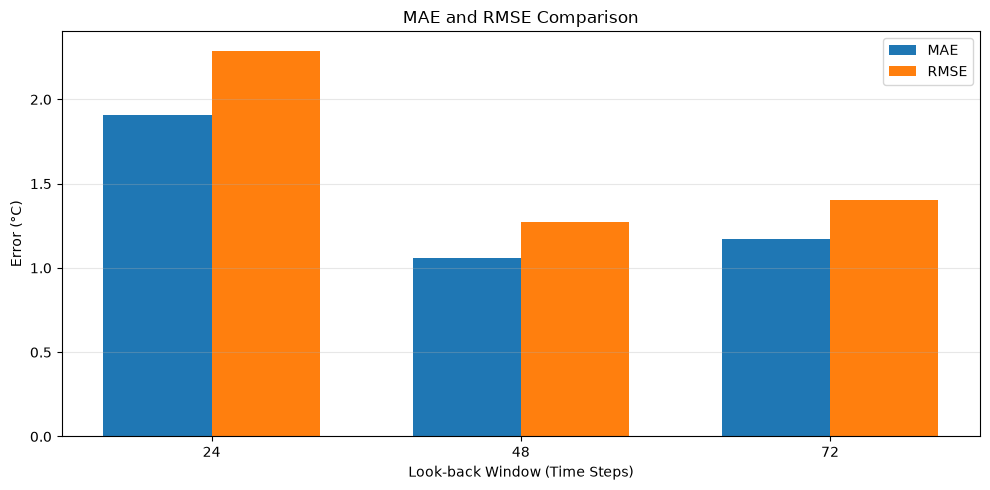

In [13]:
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    results_df["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    results_df["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    results_df["Look-back (steps)"].astype(str)
)

plt.xlabel("Look-back Window (Time Steps)")
plt.ylabel("Error (°C)")
plt.title("MAE and RMSE Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "./results/multivariate/window_metric_comparison.png",
    dpi=300
)

plt.show()

## 11. Actual vs Predicted — All Look-back Windows

This visualization compares the actual temperature values with the predictions generated by the 24-, 48-, and 72-step LSTM models over the same test period.

The comparison helps visualize how closely each model follows the observed temperature patterns.

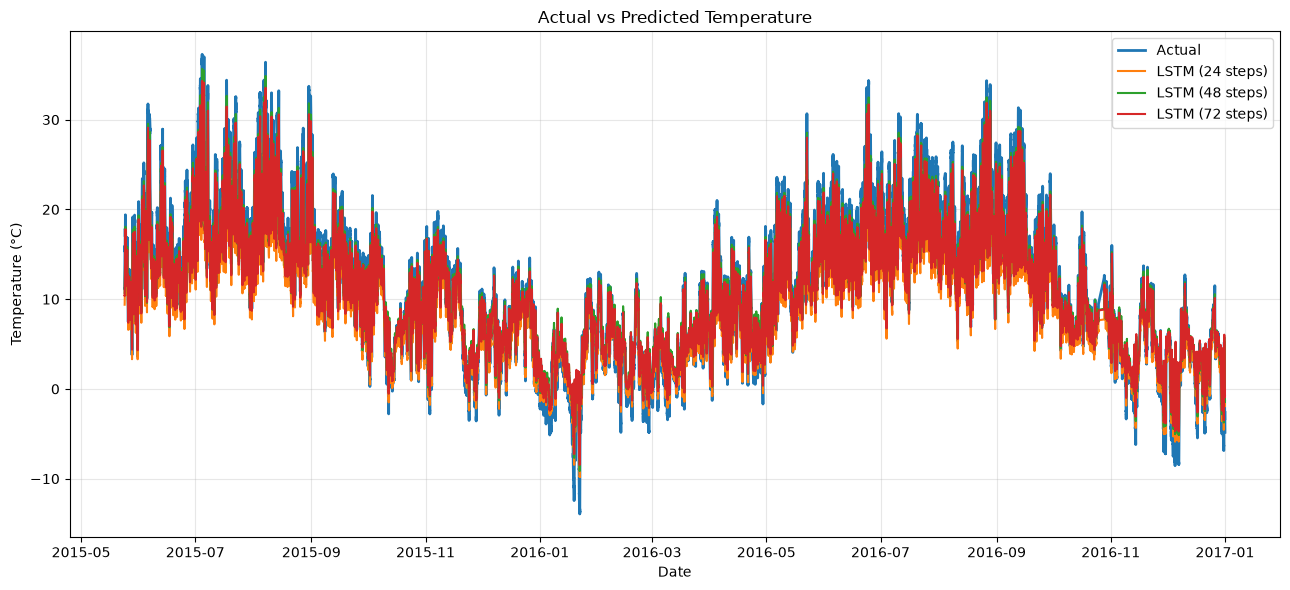

In [14]:
test_dates = df["Date Time"].iloc[train_size:].reset_index(drop=True)

plt.figure(figsize=(13, 6))

plt.plot(
    test_dates,
    predictions[24]["actual"],
    label="Actual",
    linewidth=2
)

for look_back in LOOK_BACK_WINDOWS:
    plt.plot(
        test_dates,
        predictions[look_back]["predicted"],
        label=f"LSTM ({look_back} steps)"
    )

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "./results/multivariate/all_windows_actual_vs_predicted.png",
    dpi=300
)

plt.show()

## 12. Individual Prediction Plots

Individual plots are generated for each look-back window to make the prediction behavior easier to inspect.

Each plot compares the actual temperature with the predictions produced by the corresponding LSTM model over the test period.

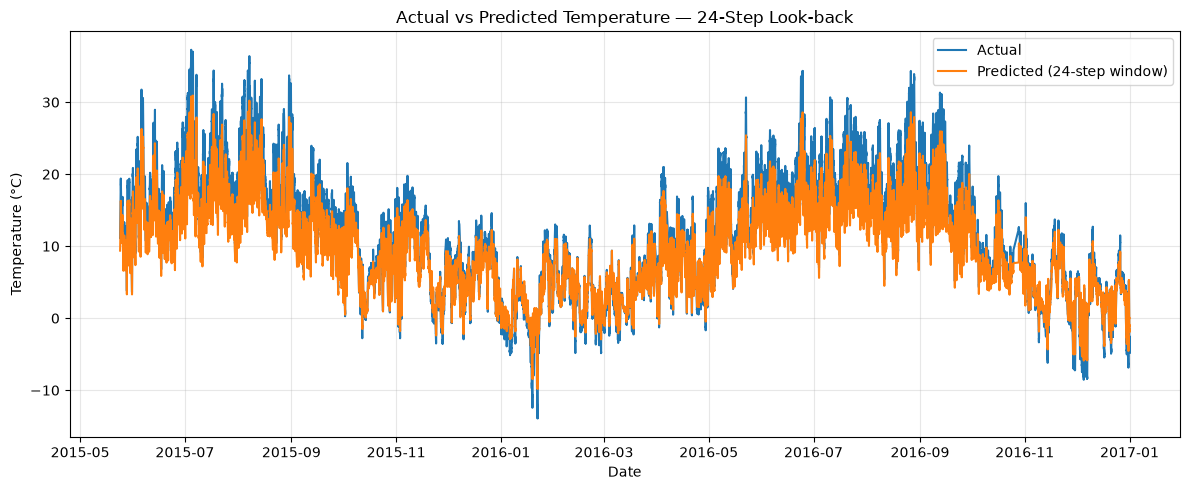

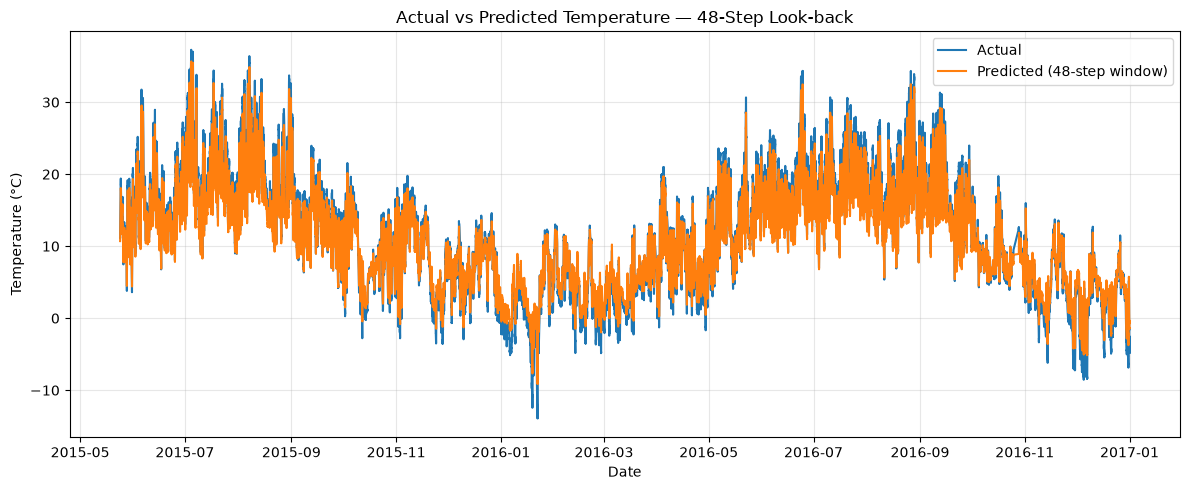

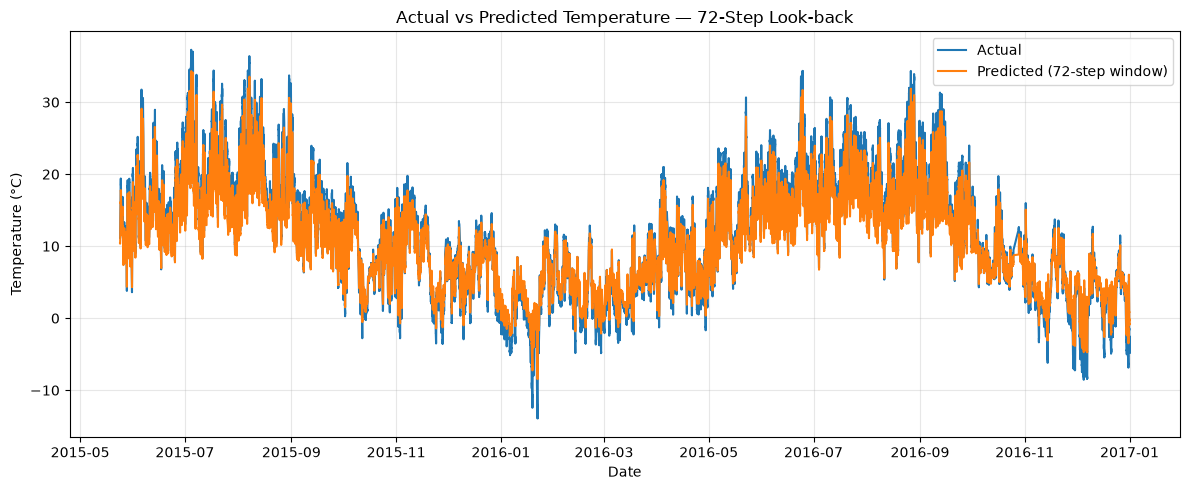

In [15]:
for look_back in LOOK_BACK_WINDOWS:
    plt.figure(figsize=(12, 5))

    plt.plot(
        test_dates,
        predictions[look_back]["actual"],
        label="Actual"
    )

    plt.plot(
        test_dates,
        predictions[look_back]["predicted"],
        label=f"Predicted ({look_back}-step window)"
    )

    plt.title(
        f"Actual vs Predicted Temperature — "
        f"{look_back}-Step Look-back"
    )
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f"./results/multivariate/prediction_{look_back}_step_window.png",
        dpi=300
    )

    plt.show()

## 13. Training and Validation Loss Comparison

The training and validation loss curves are plotted for each look-back window.

Training loss shows how well the model fits the training sequences, while validation loss shows how well the model performs on the validation portion of the training data.

The curves are used to observe the learning behavior of the three LSTM models and the effect of early stopping.

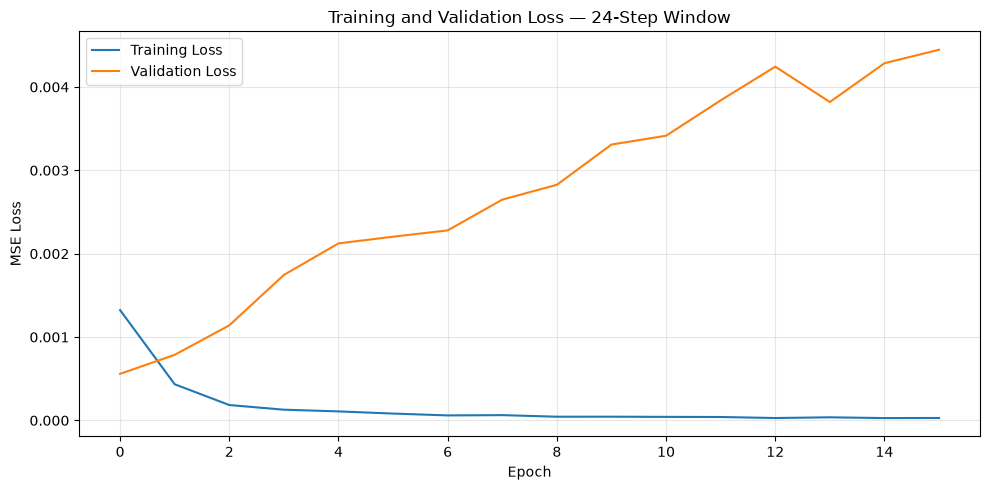

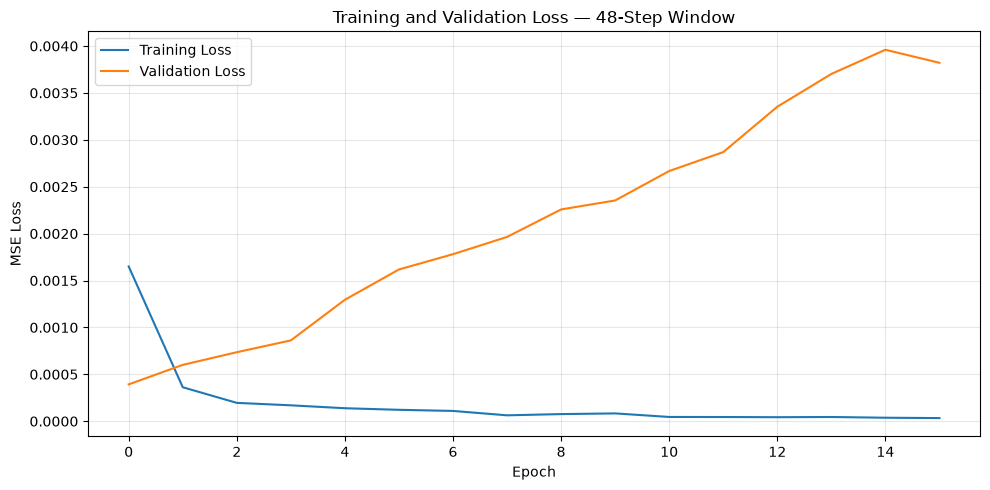

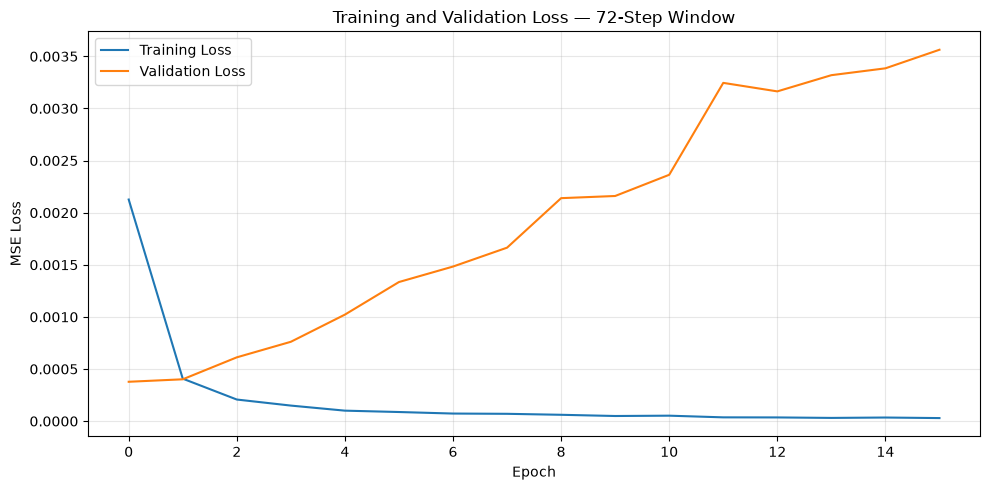

In [16]:
for look_back in LOOK_BACK_WINDOWS:
    history = histories[look_back]

    plt.figure(figsize=(10, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"Training and Validation Loss — "
        f"{look_back}-Step Window"
    )
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f"./results/multivariate/loss_{look_back}_step_window.png",
        dpi=300
    )

    plt.show()

## 14. Interpretation

### 24-Step Look-back

The 24-step model uses a shorter historical context. It captures the general temperature pattern, but its predictions show larger deviations from the actual values, particularly around sharp temperature changes.

It achieved an MAE of **1.9052 °C** and an RMSE of **2.2893 °C**.

### 48-Step Look-back

The 48-step model achieved the lowest error among the three experiments, with an MAE of **1.0612 °C** and an RMSE of **1.2735 °C**.

Its predictions follow the actual temperature series closely, indicating that this amount of historical context was effective for the given dataset and experimental configuration.

### 72-Step Look-back

The 72-step model also captures the overall temperature pattern and performs better than the 24-step model.

However, its MAE of **1.1704 °C** and RMSE of **1.4045 °C** are higher than those of the 48-step model.

The 72-step model also required substantially more training time because each input sequence contains more time steps.

### Training Behavior

The training and validation loss curves show that training loss continued to decrease while validation loss began increasing after the early epochs.

This indicates overfitting during later training epochs. Early stopping was therefore used to stop training when validation performance stopped improving, and `restore_best_weights=True` restored the weights corresponding to the best validation loss.

Overall, the experiment shows that increasing the look-back window does not necessarily improve forecasting performance. For this dataset and experimental configuration, the **48-step look-back produced the lowest MAE and RMSE**.

## 15. Conclusion

Three LSTM-based forecasting models were trained using 24-, 48-, and 72-step look-back windows on the Jena Climate dataset.

The models used 14 weather-related features as input and predicted the temperature at the next time step.

Their performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The experimental results were:

| Look-back Window | MAE (°C) | RMSE (°C) |
|---:|---:|---:|
| 24 steps | 1.9052 | 2.2893 |
| 48 steps | **1.0612** | **1.2735** |
| 72 steps | 1.1704 | 1.4045 |

For this experiment, the **48-step look-back achieved the lowest MAE and RMSE**.

The results demonstrate that the amount of historical context provided to an LSTM can affect time-series forecasting performance. A longer look-back window does not necessarily produce better predictions, as the 72-step model performed slightly worse than the 48-step model while requiring more training time.

The experiment also demonstrated the importance of chronological data splitting, feature scaling, multivariate sequence generation, early stopping, and evaluation using appropriate regression metrics.